<a href="https://colab.research.google.com/github/MasudRana2406/Comparative-Study-of-TF-IDF-BERT-and-ELECTRA-Models-for-Multi-Class-Emotion-Detection/blob/main/Comparative_Study_of_TF_IDF%2C_BERT%2C_and_ELECTRA_Models_for_Multi_Class_Emotion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Libraries


In [ ]:
# ==========================================================
# Standard Python Libraries
# ==========================================================

import re
from collections import Counter


# ==========================================================
# Data Handling
# ==========================================================

import pandas as pd
import numpy as np


# ==========================================================
# Data Visualisation
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================================
# Hugging Face Dataset
# Used to load the Emotion dataset from the Hugging Face Hub.
# ==========================================================

from datasets import load_dataset


# ==========================================================
# Hugging Face Transformers
# Used for tokenisation, model loading, training, and evaluation.
# ==========================================================

from transformers import (
    BertTokenizerFast,
    ElectraTokenizerFast,
    BertForSequenceClassification,
    ElectraForSequenceClassification,
    Trainer,
    TrainingArguments
)


# ==========================================================
# PyTorch
# Deep learning framework used by BERT.
# ==========================================================

import torch


# ==========================================================
# Traditional Machine Learning
# Used to build the baseline Logistic Regression classifier.
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


# ==========================================================
# Model Evaluation
# Used to evaluate both Logistic Regression and BERT models.
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Load the Emotion Dataset

In [ ]:
# Load the Emotion dataset from the Hugging Face Hub.
# This dataset contains text samples labelled with one of six emotions.
dataset = load_dataset("dair-ai/emotion")

## Display Dataset Information

In [ ]:
# Print basic information about the dataset, including available splits.
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## View the First Training Example

In [ ]:
# Display the first record in the training set.
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


##  Check Dataset Sizes

In [ ]:
# Print the number of samples in each split.
print("Training samples :", len(dataset["train"]))
print("Validation samples:", len(dataset["validation"]))
print("Test samples      :", len(dataset["test"]))

Training samples : 16000
Validation samples: 2000
Test samples      : 2000


## View Dataset Features

In [ ]:
# Display the dataset schema, including column names and label information.
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


## Display Emotion Labels

In [ ]:
# Retrieve the names of the emotion classes.
label_names = dataset["train"].features["label"].names

print("Emotion Labels:")
print(label_names)

Emotion Labels:
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## Display Sample Text with Emotion Name

In [ ]:
# Print the first five training examples with readable emotion labels.
for i in range(5):
    text = dataset["train"][i]["text"]
    label = dataset["train"][i]["label"]

    print(f"Text   : {text}")
    print(f"Emotion: {label_names[label]}")
    print("-" * 60)

Text   : i didnt feel humiliated
Emotion: sadness
------------------------------------------------------------
Text   : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Emotion: sadness
------------------------------------------------------------
Text   : im grabbing a minute to post i feel greedy wrong
Emotion: anger
------------------------------------------------------------
Text   : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Emotion: love
------------------------------------------------------------
Text   : i am feeling grouchy
Emotion: anger
------------------------------------------------------------


## Explore the Class Distribution

In [ ]:
# Extract all emotion labels from the training dataset.
train_labels = dataset["train"]["label"]

# Count the occurrences of each label.
label_counts = Counter(train_labels)

# Retrieve the emotion label names.
label_names = dataset["train"].features["label"].names

# Display the class distribution.
print("Class Distribution (Training Set)")
print("-" * 40)

for label_id, count in sorted(label_counts.items()):
    print(f"{label_names[label_id]:<10} : {count}")

Class Distribution (Training Set)
----------------------------------------
sadness    : 4666
joy        : 5362
love       : 1304
anger      : 2159
fear       : 1937
surprise   : 572


## Visualize the Class Distribution

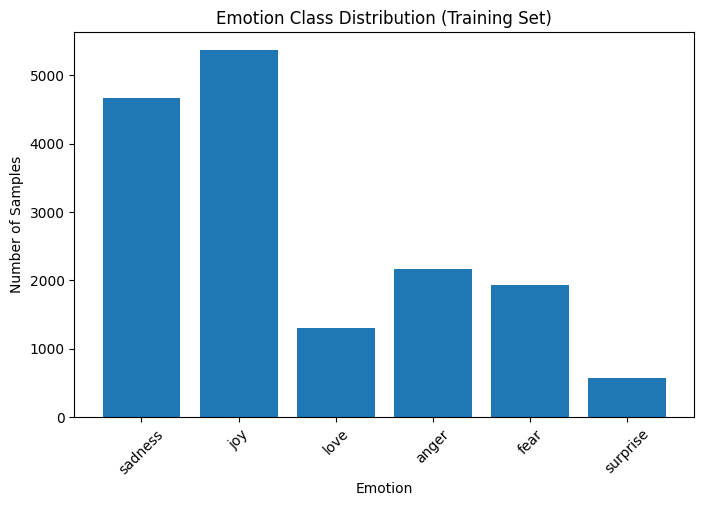

In [ ]:
# Prepare data for plotting.
emotion_names = [label_names[i] for i in sorted(label_counts.keys())]
emotion_counts = [label_counts[i] for i in sorted(label_counts.keys())]

# Create a bar chart.
plt.figure(figsize=(8, 5))
plt.bar(emotion_names, emotion_counts)

# Add chart title and axis labels.
plt.title("Emotion Class Distribution (Training Set)")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

# Rotate x-axis labels for better readability.
plt.xticks(rotation=45)

# Display the chart.
plt.show()

## Display Class Percentages

In [ ]:
# Calculate the total number of training samples.
total_samples = len(train_labels)

print("Emotion Distribution (%)")
print("-" * 40)

for label_id, count in sorted(label_counts.items()):
    percentage = (count / total_samples) * 100
    print(f"{label_names[label_id]:<10} : {percentage:.2f}%")

Emotion Distribution (%)
----------------------------------------
sadness    : 29.16%
joy        : 33.51%
love       : 8.15%
anger      : 13.49%
fear       : 12.11%
surprise   : 3.57%


## Visualize the Class Distribution Using a Pie Chart

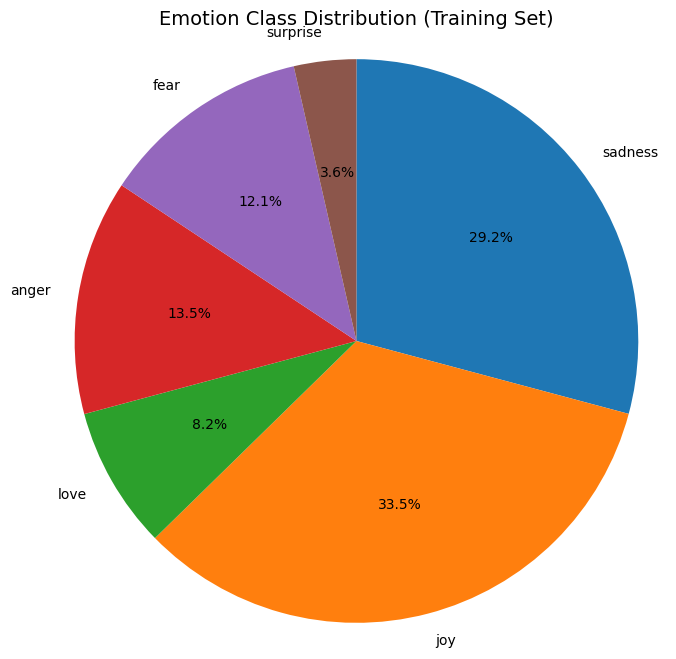

In [ ]:
# Prepare data for the pie chart
emotion_names = [label_names[i] for i in sorted(label_counts.keys())]
emotion_counts = [label_counts[i] for i in sorted(label_counts.keys())]

# Create the pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    emotion_counts,
    labels=emotion_names,
    autopct='%1.1f%%',      # Display percentage on each slice
    startangle=90,          # Rotate chart so first slice starts at the top
    counterclock=False      # Display slices in clockwise order
)

# Add a title
plt.title("Emotion Class Distribution (Training Set)", fontsize=14)

# Ensure the pie chart is circular
plt.axis('equal')

# Display the chart
plt.show()

## Check Data Quality Before Cleaning

In [ ]:
# Convert the training dataset to a Pandas DataFrame
train_df = dataset["train"].to_pandas()

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check for missing values
# ------------------------------------------------------------
print("\n1. Missing Values")
print(train_df.isnull().sum())

# ------------------------------------------------------------
# 2. Check for empty text
# ------------------------------------------------------------
empty_text = (train_df["text"].str.strip() == "").sum()
print(f"\n2. Empty Text Samples: {empty_text}")

# ------------------------------------------------------------
# 3. Check duplicate texts
# ------------------------------------------------------------
duplicates = train_df.duplicated(subset=["text"]).sum()
print(f"\n3. Duplicate Text Samples: {duplicates}")

# ------------------------------------------------------------
# 4. Text length statistics
# ------------------------------------------------------------
train_df["text_length"] = train_df["text"].str.len()

print("\n4. Text Length Statistics")
print(train_df["text_length"].describe())

# ------------------------------------------------------------
# 5. Check for URLs
# ------------------------------------------------------------
url_count = train_df["text"].str.contains(r"http[s]?://|www\.", regex=True).sum()
print(f"\n5. Texts containing URLs: {url_count}")

# ------------------------------------------------------------
# 6. Check for HTML tags
# ------------------------------------------------------------
html_count = train_df["text"].str.contains(r"<.*?>", regex=True).sum()
print(f"\n6. Texts containing HTML tags: {html_count}")

# ------------------------------------------------------------
# 7. Check for multiple spaces
# ------------------------------------------------------------
space_count = train_df["text"].str.contains(r"\s{2,}", regex=True).sum()
print(f"\n7. Texts with extra spaces: {space_count}")

print("\nData Quality Check Completed.")

DATA QUALITY CHECK

1. Missing Values
text     0
label    0
dtype: int64

2. Empty Text Samples: 0

3. Duplicate Text Samples: 31

4. Text Length Statistics
count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
Name: text_length, dtype: float64

5. Texts containing URLs: 0

6. Texts containing HTML tags: 0

7. Texts with extra spaces: 0

Data Quality Check Completed.


## Remove Duplicate Text Samples

In [ ]:
# Count duplicates before removal
before_duplicates = dataset["train"].num_rows

# Remove duplicate text examples from the training dataset
dataset["train"] = dataset["train"].to_pandas().drop_duplicates(
    subset=["text"]
)

# Convert back to Hugging Face Dataset format
from datasets import Dataset

dataset["train"] = Dataset.from_pandas(
    dataset["train"],
    preserve_index=False
)

# Count samples after removal
after_duplicates = dataset["train"].num_rows


print("Samples before removing duplicates:", before_duplicates)
print("Samples after removing duplicates :", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Samples before removing duplicates: 16000
Samples after removing duplicates : 15969
Duplicates removed: 31


## Minimal Text Cleaning

In [ ]:
def clean_text(example):
    """
    Minimal preprocessing for BERT.

    Operations:
    - Convert text to lowercase
    - Remove unnecessary whitespace
    """

    text = example["text"]

    # Convert text to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    example["text"] = text

    return example

## Apply Cleaning

In [ ]:
# Apply preprocessing to train, validation, and test sets

dataset = dataset.map(clean_text)


print(dataset)

Map:   0%|          | 0/15969 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 15969
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## Check Cleaned Examples

In [ ]:
for i in range(5):

    print("Text:")
    print(dataset["train"][i]["text"])

    print("Label:")
    print(dataset["train"][i]["label"])

    print("-" * 50)

Text:
i didnt feel humiliated
Label:
0
--------------------------------------------------
Text:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label:
0
--------------------------------------------------
Text:
im grabbing a minute to post i feel greedy wrong
Label:
3
--------------------------------------------------
Text:
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label:
2
--------------------------------------------------
Text:
i am feeling grouchy
Label:
3
--------------------------------------------------


## Final Data Validation

In [ ]:
train_check = dataset["train"].to_pandas()

print("Missing Values:")
print(train_check.isnull().sum())

print("\nDuplicate Texts:")
print(
    train_check.duplicated(subset=["text"]).sum()
)

print("\nFinal Dataset Size:")
print(train_check.shape)

Missing Values:
text     0
label    0
dtype: int64

Duplicate Texts:
0

Final Dataset Size:
(15969, 2)


## Base Model : Logistic Regression

## Prepare Text Data for Logistic Regression

In [ ]:
# Convert Hugging Face dataset into pandas

train_df = dataset["train"].to_pandas()

validation_df = dataset["validation"].to_pandas()

test_df = dataset["test"].to_pandas()


# Separate input text and labels

X_train = train_df["text"]
y_train = train_df["label"]


X_test = test_df["text"]
y_test = test_df["label"]


print(X_train.shape)
print(X_test.shape)

(15969,)
(2000,)


## TF-IDF Vectorization

In [ ]:
# Convert text into numerical TF-IDF features

tfidf = TfidfVectorizer(

    # Maximum vocabulary size
    max_features=10000,

    # Consider important words only
    stop_words="english"
)


# Fit TF-IDF on training data

X_train_tfidf = tfidf.fit_transform(
    X_train
)


# Transform test data

X_test_tfidf = tfidf.transform(
    X_test
)


print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Training TF-IDF shape: (15969, 10000)
Testing TF-IDF shape: (2000, 10000)


## Train Logistic Regression Baseline

In [ ]:

# Create classifier

lr_model = LogisticRegression(

    max_iter=1000
)


# Train model

lr_model.fit(
    X_train_tfidf,
    y_train
)


print(
    "Logistic Regression training completed"
)

Logistic Regression training completed


## Evaluate Logistic Regression

In [ ]:
lr_predictions = lr_model.predict(
    X_test_tfidf
)


print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.90      0.92      0.91       581
         joy       0.85      0.95      0.89       695
        love       0.78      0.64      0.70       159
       anger       0.89      0.81      0.85       275
        fear       0.86      0.82      0.84       224
    surprise       0.89      0.50      0.64        66

    accuracy                           0.87      2000
   macro avg       0.86      0.77      0.81      2000
weighted avg       0.87      0.87      0.86      2000



## BERT Model

## Load BERT Tokenizer

In [ ]:
# Load the tokenizer corresponding to the BERT base uncased model "uncased" means the model treats uppercase and lowercase words equally.

tokenizer = BertTokenizerFast.from_pretrained(
    "bert-base-uncased"
)

print("BERT tokenizer loaded successfully")

BERT tokenizer loaded successfully


## Text Tokenization

In [ ]:
# Select one example from the training dataset
sample_text = dataset["train"][1]["text"]

print("Original Text:")
print(sample_text)

# Apply BERT tokenizer
tokens = tokenizer.tokenize(sample_text)

print("\nBERT Tokens:")
print(tokens)

Original Text:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

BERT Tokens:
['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']


##  Convert Tokens to Token IDs

In [ ]:
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Token IDs:")
print(token_ids)

Token IDs:
[1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300]


## Create Tokenization Function

In [ ]:
def tokenize_data(example):
    """
    Tokenizes text using BERT tokenizer.

    Parameters:
    example:
        A single dataset example containing text.

    Returns:
        Tokenized text containing:
        - input_ids
        - attention_mask
    """

    return tokenizer(
        example["text"],

        # Maximum sequence length.
        # Text longer than this will be truncated.
        # Shorter text will be padded.
        max_length=128,

        # Cut sentences longer than max_length
        truncation=True,

        # Add padding tokens
        padding="max_length"
    )

## Tokenize Entire Dataset

In [ ]:

tokenized_dataset = dataset.map(
    tokenize_data,

    # Apply function to individual examples
    batched=True
)


print(tokenized_dataset)

Map:   0%|          | 0/15969 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15969
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


## Inspect Tokenized Example

In [ ]:
example = tokenized_dataset["train"][1]


print("Original Text:")
print(example["text"])

print("\nInput IDs:")
print(example["input_ids"])

print("\nAttention Mask:")
print(example["attention_mask"])

print("\nLabel:")
print(example["label"])

Original Text:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Input IDs:
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Label:

## Decode Token IDs Back to Text

In [ ]:
decoded_text = tokenizer.decode(
    example["input_ids"],
    skip_special_tokens=True
)

print("Decoded Text:")
print(decoded_text)

Decoded Text:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


## Check Dataset Splits

In [ ]:
# Display available dataset splits
print(tokenized_dataset)

# Display number of samples in each split

print("\nDataset Sizes")
print("-" * 40)

print("Training samples   :", len(tokenized_dataset["train"]))
print("Validation samples :", len(tokenized_dataset["validation"]))
print("Test samples       :", len(tokenized_dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15969
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Dataset Sizes
----------------------------------------
Training samples   : 15969
Validation samples : 2000
Test samples       : 2000


##  Check Class Distribution Across Splits

In [ ]:
# Emotion label mapping
label_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}


for split in ["train", "validation", "test"]:

    print("\n" + split.upper())
    print("-" * 40)

    # Extract labels
    labels = tokenized_dataset[split]["label"]

    # Labels are already integers, no conversion needed
    distribution = Counter(labels)

    # Display class counts
    for label_id, count in sorted(distribution.items()):

        print(
            f"{label_names[label_id]:<10}: {count}"
        )


TRAIN
----------------------------------------
sadness   : 4664
joy       : 5350
love      : 1299
anger     : 2155
fear      : 1933
surprise  : 568

VALIDATION
----------------------------------------
sadness   : 550
joy       : 704
love      : 178
anger     : 275
fear      : 212
surprise  : 81

TEST
----------------------------------------
sadness   : 581
joy       : 695
love      : 159
anger     : 275
fear      : 224
surprise  : 66


In [ ]:
print(tokenized_dataset["train"].features)

{'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## Convert Dataset Format for PyTorch

In [ ]:
# Remove unnecessary columns
# BERT only needs:
# - input_ids
# - attention_mask
# - label

tokenized_dataset = tokenized_dataset.remove_columns(
    ["text"]
)


# Set dataset format to PyTorch tensors

tokenized_dataset.set_format(
    "torch"
)

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15969
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


## Define Model Parameters

In [ ]:
# The Emotion dataset contains six emotion categories:
# sadness, joy, love, anger, fear, surprise

num_labels = 6


# Mapping between labels and emotion names

id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}


label2id = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}

## Load BERT Model

In [ ]:
model = BertForSequenceClassification.from_pretrained(

    "bert-base-uncased",

    # Number of output classes
    num_labels=num_labels,

    # Store label names inside the model
    id2label=id2label,
    label2id=label2id
)

print("BERT model loaded successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully


## Training Configuration

In [ ]:
training_args = TrainingArguments(

    # Folder where model checkpoints will be saved
    output_dir="./bert-emotion-model",

    # Number of training epochs
    num_train_epochs=3,

    # Number of samples processed in each training step
    per_device_train_batch_size=16,

    # Number of samples processed during validation
    per_device_eval_batch_size=16,

    # Learning rate for AdamW optimizer
    learning_rate=2e-5,

    # Evaluate model after each epoch
    eval_strategy="epoch",

    # Save model checkpoint after each epoch
    save_strategy="epoch",

    # Automatically load the best model after training
    load_best_model_at_end=True,

    # Select best model based on F1-score
    metric_for_best_model="f1",

    # Prevent overfitting
    weight_decay=0.01,

    # Directory for logs
    logging_dir="./logs",

    # Print training information every 100 steps
    logging_steps=100,


)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Create Hugging Face Trainer

In [ ]:

def compute_metrics(eval_prediction):
    """
    Calculate evaluation metrics for the BERT model.

    Metrics:
    - Accuracy
    - Precision (Weighted)
    - Recall (Weighted)
    - F1-score (Weighted)
    """

    # Model outputs and true labels
    logits, labels = eval_prediction

    # Convert logits into predicted class labels
    predictions = logits.argmax(axis=-1)

    # Calculate evaluation metrics
    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    # Return metrics as a dictionary
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
trainer = Trainer(

    # BERT model
    model=model,


    # Training configuration
    args=training_args,


    # Training dataset
    train_dataset=tokenized_dataset["train"],


    # Validation dataset
    eval_dataset=tokenized_dataset["validation"],


    # Evaluation function
    compute_metrics=compute_metrics
)


print("Trainer created successfully")

Trainer created successfully


## Train BERT Model

In [ ]:
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.201073,0.203412,0.927500,0.931537,0.927500,0.928087
2,0.117709,0.158719,0.940500,0.941911,0.940500,0.940007
3,0.075190,0.161794,0.934000,0.933745,0.934000,0.933814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

In [ ]:
#!pip uninstall -y torchvision

## Save Final Model

In [ ]:

trainer.save_model(
    "./bert-emotion-final"
)

tokenizer.save_pretrained(
    "./bert-emotion-final"
)


print("Model saved successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully


## Generate Predictions from BERT

In [ ]:
# Predict emotion classes for test data

bert_predictions = trainer.predict(
    tokenized_dataset["test"]
)


# Extract predicted labels

bert_pred_labels = (
    bert_predictions.predictions
    .argmax(axis=1)
)


# True labels

bert_true_labels = (
    bert_predictions.label_ids
)

## Define Evaluation Metrics

## Evaluate Fine-Tuned BERT Model

In [ ]:
# Evaluate the trained BERT model using the unseen test dataset

bert_results = trainer.evaluate(
    tokenized_dataset["test"]
)

print("BERT Test Results")
print("=" * 40)

for key, value in bert_results.items():
    print(f"{key}: {value:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.075190,0.183812,3,0.928000,0.929746,0.928000,0.926090


BERT Test Results
eval_loss: 0.1838
eval_accuracy: 0.9280
eval_precision: 0.9297
eval_recall: 0.9280
eval_f1: 0.9261


## BERT Classification Report

In [ ]:
print(
    classification_report(
        bert_true_labels,
        bert_pred_labels,
        target_names=list(label_names.values())
    )
)

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       581
         joy       0.93      0.96      0.95       695
        love       0.88      0.77      0.82       159
       anger       0.94      0.90      0.92       275
        fear       0.84      0.96      0.90       224
    surprise       1.00      0.58      0.73        66

    accuracy                           0.93      2000
   macro avg       0.93      0.86      0.88      2000
weighted avg       0.93      0.93      0.93      2000



## BERT Confusion Matrix

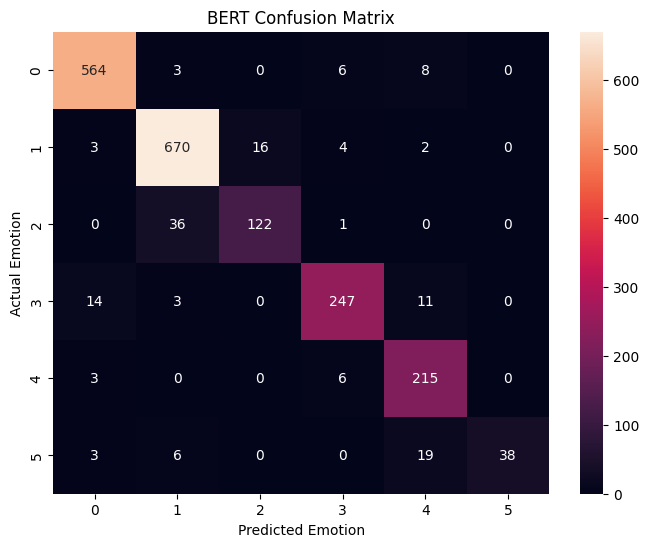

In [ ]:
cm = confusion_matrix(
    bert_true_labels,
    bert_pred_labels
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)


plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.title(
    "BERT Confusion Matrix"
)

plt.show()

## Load ELECTRA tokenizer

In [ ]:
electra_tokenizer = ElectraTokenizerFast.from_pretrained(
    "google/electra-base-discriminator"
)

print("ELECTRA tokenizer loaded successfully")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

ELECTRA tokenizer loaded successfully


## Tokenization function

In [ ]:

def tokenize_data(example):
    """
    Tokenizes text using electra tokenizer.

    Parameters:
    example:
        A single dataset example containing text.

    Returns:
        Tokenized text containing:
        - input_ids
        - attention_mask
    """

    return electra_tokenizer(
        example["text"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

## Load ELECTRA model

In [ ]:
electra_model = ElectraForSequenceClassification.from_pretrained(

    "google/electra-base-discriminator",

    num_labels=num_labels,

    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings_project.weight                 | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

## Create Trainer

In [ ]:
electra_trainer = Trainer(

    model=electra_model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["validation"],

    compute_metrics=compute_metrics
)

## Train ELECTRA

In [ ]:
electra_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.309384,0.282563,0.920000,0.923407,0.920000,0.920573
2,0.167613,0.208115,0.934500,0.936064,0.934500,0.935034
3,0.096379,0.189568,0.936000,0.936614,0.936000,0.936181


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2997, training_loss=0.3509079608910872, metrics={'train_runtime': 1056.854, 'train_samples_per_second': 45.33, 'train_steps_per_second': 2.836, 'total_flos': 3151328506246656.0, 'train_loss': 0.3509079608910872, 'epoch': 3.0})

## Test ELECTRA

In [ ]:
electra_predictions = electra_trainer.predict(
    tokenized_dataset["test"]
)

electra_pred_labels = (
    electra_predictions.predictions.argmax(axis=1)
)

electra_true_labels = (
    electra_predictions.label_ids
)

## Calculate metrics

In [ ]:
electra_accuracy = accuracy_score(
    electra_true_labels,
    electra_pred_labels
)

electra_precision = precision_score(
    electra_true_labels,
    electra_pred_labels,
    average="weighted"
)

electra_recall = recall_score(
    electra_true_labels,
    electra_pred_labels,
    average="weighted"
)

electra_f1 = f1_score(
    electra_true_labels,
    electra_pred_labels,
    average="weighted"
)

## Model Performance Comparison

In [ ]:
# Calculate Logistic Regression metrics

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)


lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted"
)


lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted"
)


lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="weighted"
)



# BERT metrics

bert_accuracy = accuracy_score(
    bert_true_labels,
    bert_pred_labels
)


bert_precision = precision_score(
    bert_true_labels,
    bert_pred_labels,
    average="weighted"
)


bert_recall = recall_score(
    bert_true_labels,
    bert_pred_labels,
    average="weighted"
)


bert_f1 = f1_score(
    bert_true_labels,
    bert_pred_labels,
    average="weighted"
)



# Create comparison dataframe

import pandas as pd


comparison = pd.DataFrame({

    "Model":
    [
        "Logistic Regression + TF-IDF",
        "Fine-tuned BERT"
    ],

    "Accuracy":
    [
        lr_accuracy,
        bert_accuracy
    ],

    "Precision":
    [
        lr_precision,
        bert_precision
    ],

    "Recall":
    [
        lr_recall,
        bert_recall
    ],

    "F1-score":
    [
        lr_f1,
        bert_f1
    ]

})


comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression + TF-IDF,0.867,0.866980,0.867,0.86328
1,Fine-tuned BERT,0.928,0.929746,0.928,0.92609


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression + TF-IDF",
        "Fine-tuned BERT",
        "Fine-tuned ELECTRA"
    ],

    "Accuracy":[
        lr_accuracy,
        bert_accuracy,
        electra_accuracy
    ],

    "Precision":[
        lr_precision,
        bert_precision,
        electra_precision
    ],

    "Recall":[
        lr_recall,
        bert_recall,
        electra_recall
    ],

    "F1-score":[
        lr_f1,
        bert_f1,
        electra_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression + TF-IDF,0.867,0.866980,0.867,0.863280
1,Fine-tuned BERT,0.928,0.929746,0.928,0.926090
2,Fine-tuned ELECTRA,0.929,0.931088,0.929,0.929746


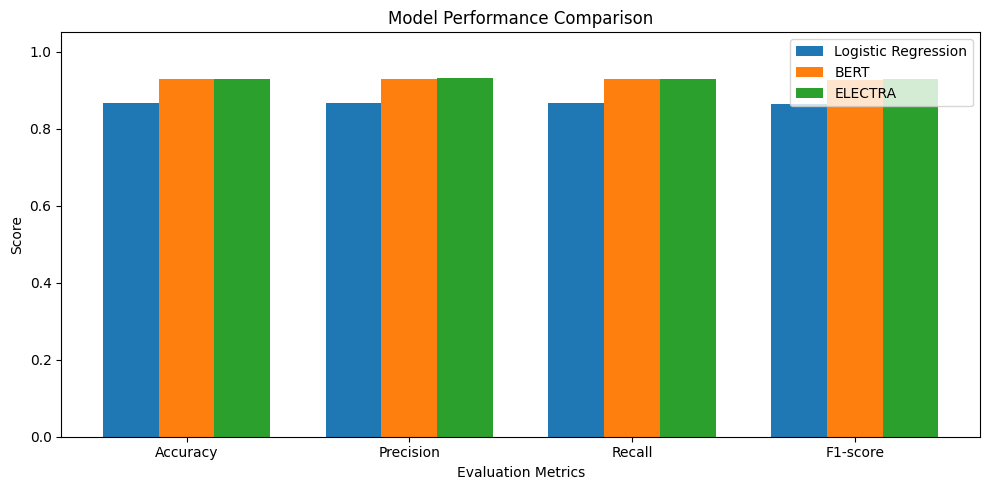

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
bert_scores = [bert_accuracy, bert_precision, bert_recall, bert_f1]
electra_scores = [electra_accuracy, electra_precision, electra_recall, electra_f1]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x-width, lr_scores, width,
        label="Logistic Regression")

plt.bar(x, bert_scores, width,
        label="BERT")

plt.bar(x+width, electra_scores, width,
        label="ELECTRA")

plt.xticks(x, metrics)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.ylim(0,1.05)

plt.legend()

plt.tight_layout()
plt.show()